# Background Knowledge: Whitelisting & Blacklisting Edges

Domain experts often know that certain causal relationships are impossible
(e.g. temperature cannot cause latitude) or must exist (e.g. upstream flow
causes downstream flow). **CDNOTS+, CDNOTS, and CEDAR** all support encoding
this knowledge via forbidden (blacklist) and required (whitelist) constraints.

Two levels of constraint are available:

| Constraint | Level | Enforced at | Mechanism |
|------------|-------|-------------|-----------|
| **Forbidden edge** | Direct (path length 1) | Skeleton phase | Removes the specific edge before CI testing begins |
| **Required edge** | Direct (path length 1) | Skeleton phase | Skips CI testing — edge is always kept in skeleton |
| **Required ancestor** | Path (any length) | Post-orientation | (1) Orient undirected edges on existing semi-directed path; (2) bridge via best-correlated skeleton neighbor; (3) force-add direct edge at AR-residualized best lag |
| **Forbidden ancestor** | Path (any length) | Post-orientation + Meek | Remove direct A→D edges + all lag-shifted copies; remove last-hop Y→D for surviving multi-hop paths; block new Meek orientations that would recreate the path |

**Part 1** (Examples 1–3): edge-level constraints with CDNOTS+ using the classic `background_knowledge=` API.  
**Part 2** (Examples 4–5): path-level constraints with `AncestralKnowledge` (CDNOTS+).  
**Part 3** (Example 6): background knowledge with CEDAR.

Each edge constraint tuple is `(cause, effect, cause_lag, effect_lag)` — lags are 0-indexed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from causalts.synthetic_data.synthetic_datasets import load_dataset
from causalts.ci_tests import ParCorrGPU
from causalts import run_cdnots_plus, run_cedar, AncestralKnowledge
from causalts.utils import evaluate_graph

## Part 1 — CDNOTS+: Edge-Level Constraints

### Setup: Baseline Discovery

Run CDNOTS+ on the ex2 dataset (6-variable linear, T=500) without any
background knowledge to establish a baseline.

Baseline: F1=0.833, Precision=0.769, TPR=0.909, SHD=4


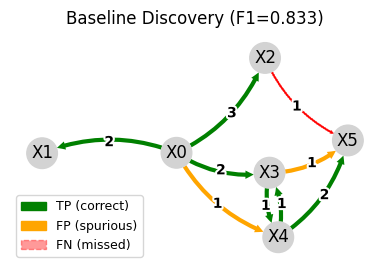


False positives (3):
  X0 -> X4 at lag 1
  X3 -> X5 at lag 1
  X5 -> X5 at lag 2

False negatives (1):
  X2 -> X5 at lag 1


In [2]:
result = load_dataset("ex2", seed=42, T=500)
df, gt = result["df"], result["ground_truth"]
d = df.shape[1]
var_names = list(df.columns)
max_lag = gt.shape[2] - 1

ci_test = ParCorrGPU(np.zeros((2, 2)), device="cpu")
_res = run_cdnots_plus(
    df=df, indep_test=ci_test, num_lags=max_lag,
    include_C=False, alpha=0.05, lag_verify=True,
    verbose=False, show_progress=False,
)
g = _res.cg_tig[:d, :d, :]
m = evaluate_graph(g, gt)
print(f"Baseline: F1={m['F1']:.3f}, Precision={m['Precision']:.3f}, TPR={m['TPR']:.3f}, SHD={m['SHD']}")
import matplotlib.pyplot as plt
from causalts.plotting.compare import compare_graphs

fig, ax = plt.subplots(figsize=(4, 5))
_, _, baseline_pos = compare_graphs(
    gt, g, var_names=var_names, fig_ax=(fig, ax),
    title=f"Baseline Discovery (F1={m['F1']:.3f})",
    legend_loc="lower left",
    arrow_linewidth=3,
    node_layout="sfdp",
    node_label_size=12,
    node_size=0.2,
    return_pos=True,
)
plt.tight_layout()
plt.show()

# Identify false positives and false negatives
fps = np.argwhere((g == 1) & (gt == 0))
fns = np.argwhere((g == 0) & (gt == 1))
print(f"\nFalse positives ({len(fps)}):")
for c, e, l in fps:
    print(f"  {var_names[c]} -> {var_names[e]} at lag {l}")
print(f"\nFalse negatives ({len(fns)}):")
for c, e, l in fns:
    print(f"  {var_names[c]} -> {var_names[e]} at lag {l}")

## Example 1: Forbidden Edges (Blacklist)

Suppose domain knowledge tells us that a specific discovered edge is
impossible. We can forbid it and re-run discovery.

In [3]:
# Forbid all false positives identified above
forbidden_edges = [(var_names[c], var_names[e], int(l), 0) for c, e, l in fps]
print("Forbidding:", forbidden_edges)

bk = _res.make_background_knowledge(
    forbidden=forbidden_edges,
)

ci_test2 = ParCorrGPU(np.zeros((2, 2)), device="cpu")
_res = run_cdnots_plus(
    df=df, indep_test=ci_test2, num_lags=max_lag,
    include_C=False, alpha=0.05, lag_verify=True,
    verbose=False, show_progress=False,
    background_knowledge=bk,
)
g2 = _res.cg_tig[:d, :d, :]
m2 = evaluate_graph(g2, gt)
print(f"With forbidden edges: F1={m2['F1']:.3f}, Precision={m2['Precision']:.3f}, TPR={m2['TPR']:.3f}, SHD={m2['SHD']}")
print(f"Improvement: F1 {m['F1']:.3f} -> {m2['F1']:.3f}")

Forbidding: [('X0', 'X4', 1, 0), ('X3', 'X5', 1, 0), ('X5', 'X5', 2, 0)]
With forbidden edges: F1=0.909, Precision=0.909, TPR=0.909, SHD=2
Improvement: F1 0.833 -> 0.909


## Example 2: Required Edges (Whitelist)

Required edges prevent the algorithm from removing them during skeleton
discovery, even if the CI test finds them independent. This is useful when
you know a causal link exists from domain knowledge but the statistical test
lacks power to detect it.

In [4]:
# Require all false negatives (edges the algorithm missed but are in ground truth)
required_edges = [(var_names[c], var_names[e], int(l), 0) for c, e, l in fns]
print("Requiring:", required_edges)

bk3 = _res.make_background_knowledge(
    required=required_edges,
)

ci_test3 = ParCorrGPU(np.zeros((2, 2)), device="cpu")
_res = run_cdnots_plus(
    df=df, indep_test=ci_test3, num_lags=max_lag,
    include_C=False, alpha=0.05, lag_verify=True,
    verbose=False, show_progress=False,
    background_knowledge=bk3,
)
g3 = _res.cg_tig[:d, :d, :]
m3 = evaluate_graph(g3, gt)
print(f"With required edges: F1={m3['F1']:.3f}, Precision={m3['Precision']:.3f}, TPR={m3['TPR']:.3f}, SHD={m3['SHD']}")
print(f"Improvement: F1 {m['F1']:.3f} -> {m3['F1']:.3f}")

Requiring: [('X2', 'X5', 1, 0)]
With required edges: F1=0.957, Precision=0.917, TPR=1.000, SHD=1
Improvement: F1 0.833 -> 0.957


## Example 3: Combined — Forbid + Require

In practice, you might know both: certain edges are impossible *and* certain
edges must exist. Both can be combined in a single call.

In [5]:
bk4 = _res.make_background_knowledge(
    forbidden=forbidden_edges,
    required=required_edges,
)

ci_test4 = ParCorrGPU(np.zeros((2, 2)), device="cpu")
_res = run_cdnots_plus(
    df=df, indep_test=ci_test4, num_lags=max_lag,
    include_C=False, alpha=0.05, lag_verify=True,
    verbose=False, show_progress=False,
    background_knowledge=bk4,
)
g4 = _res.cg_tig[:d, :d, :]
m4 = evaluate_graph(g4, gt)
print(f"Combined (forbid + require): F1={m4['F1']:.3f}, Precision={m4['Precision']:.3f}, TPR={m4['TPR']:.3f}, SHD={m4['SHD']}")
print(f"Improvement: F1 {m['F1']:.3f} -> {m4['F1']:.3f}")

Combined (forbid + require): F1=0.957, Precision=0.917, TPR=1.000, SHD=1
Improvement: F1 0.833 -> 0.957


## Visual Comparison

Network graphs showing TP (green), FP (orange), and FN (red dashed) edges for each scenario.

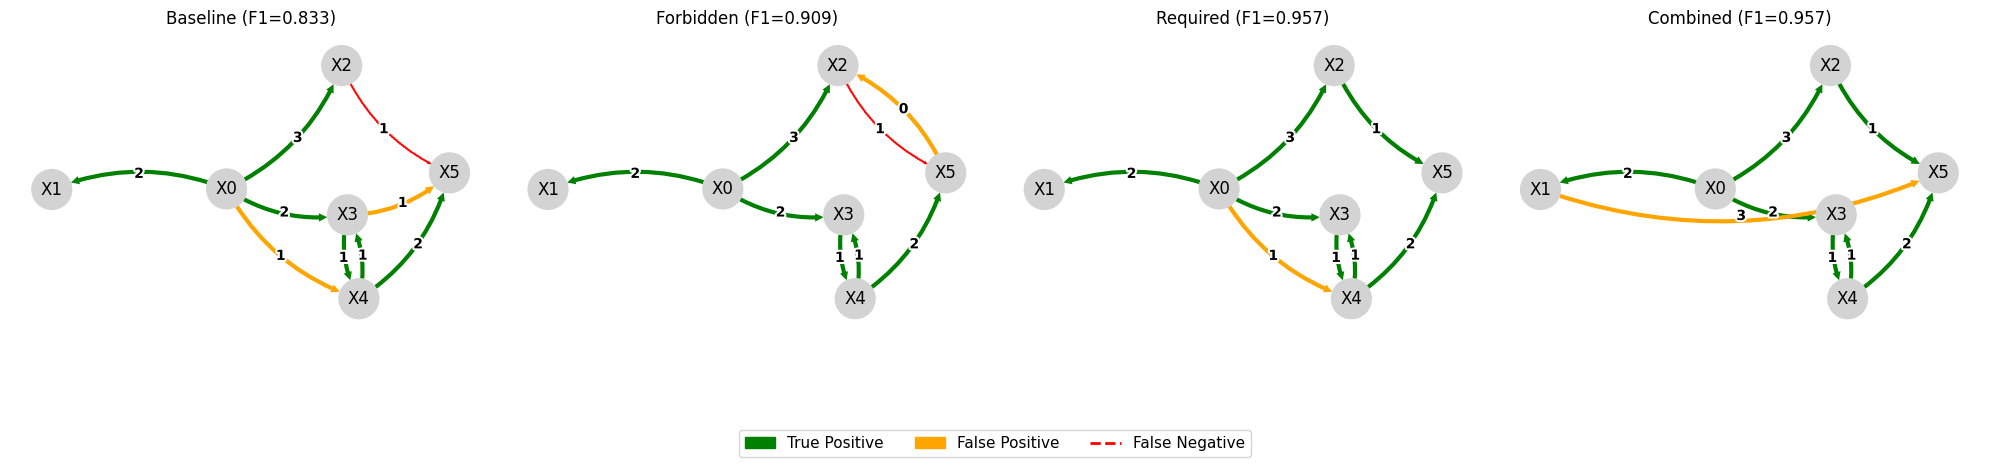

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

scenarios = [
    (g,  f"Baseline (F1={m['F1']:.3f})"),
    (g2, f"Forbidden (F1={m2['F1']:.3f})"),
    (g3, f"Required (F1={m3['F1']:.3f})"),
    (g4, f"Combined (F1={m4['F1']:.3f})"),
]

for ax, (g_est, title) in zip(axes, scenarios):
    compare_graphs(
        gt, g_est,
        var_names=var_names,
        fig_ax=(fig, ax),
        node_pos=baseline_pos,
        title=title,
        show_legend=False,
        return_pos=True,
    )

import matplotlib.patches as mpatches
import matplotlib.lines as mlines
legend_handles = [
    mpatches.Patch(color="green", label="True Positive"),
    mpatches.Patch(color="orange", label="False Positive"),
    mlines.Line2D([], [], color="red", linestyle="dashed", linewidth=2, label="False Negative"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

> **Note on cascades (edge constraints):** `forbidden_edge` and `required_edge` change the skeleton, which changes the CI conditioning sets for all remaining edges. The final graph can therefore change beyond just the specified edge. This cascade applies to **edge-level constraints only** — path constraints (`required_ancestor`, `forbidden_ancestor`) are enforced post-orientation after all CI tests have completed.

---
## Part 2: Ancestral Constraints with `AncestralKnowledge`

The `AncestralKnowledge` class is a unified interface for all knowledge types.
Edge constraints (Part 1) are a special case — path of length 1.

```python
ak = AncestralKnowledge()
ak.add_forbidden_edge("X0", "X4", cause_lag=1)      # removes X0(t-1)→X4 from skeleton
ak.add_required_edge("X2", "X5", cause_lag=1)        # keeps X2(t-1)→X5 in skeleton always
ak.add_required_ancestor("X2", "X5")                 # ensures a directed path X2→…→X5 exists
ak.add_forbidden_ancestor("X4", "X0")                # removes all directed paths X4→…→X0

run_cdnots_plus(df, indep_test, ..., knowledge=ak)   # replaces background_knowledge=
```

### How `required_ancestor(A, D)` works:
1. **Already satisfied?** Check if any lag copy of A is already a directed ancestor of D — if yes, done.
2. **Best lag selection**: rank lags 1..max_lag by |Pearson r| between A(t-k) and the AR(1)-residualized D (i.e. D residualized on its own lag-1 to isolate A's direct causal signal, excluding lag-0).
3. **Orient existing skeleton path**: BFS from A(t-k) to D(t), excluding other lag copies of D as intermediate nodes (prevents autoregressive stepping-stone paths). Orient any undirected edges along the path.
4. **Bridge**: if no skeleton path, look for a direct skeleton neighbor N of A(t-k) that already has a path to D; orient A→N.
5. **Force-add**: if no bridge, add the direct edge A(t-k)→D.

### How `forbidden_ancestor(A, D)` works:
1. **Pass 1** (direct + lag-shifted copies): remove A(t-k)→D for all k, plus all lag-shifted copies A(t-k-1)→D(t-1), A(t-k-2)→D(t-2), …
2. **Pass 2** (multi-hop): if a path A→…→Y→D still exists through other variables after Pass 1 + Meek, remove the last-hop Y→D edge.
3. **Proactive Meek guard**: during all Meek passes, any orientation that would recreate a forbidden path is blocked.

> **Warning:** `forbidden_ancestor` is stronger than `forbidden_edge`. If A→X→D is a genuine causal path in the true graph, enforcing `forbidden_ancestor(A, D)` will remove X→D (a true positive). Use `add_forbidden_edge` when you only want to forbid the direct connection.

## Example 4: Required Ancestor (Path Constraint)

The baseline missed `X2 → X5` at lag 1 (false negative). With
`required_ancestor("X2", "X5")` we express: *X2 must causally reach X5
somewhere in the graph* — without specifying the exact lag or whether
the connection is direct or indirect.

The AR(1)-residualized |Pearson r| selects the best lag: X5 is residualized
on X5(t-1) via OLS to remove its own autoregressive component, then X2's lags
are ranked by correlation with the residuals. This isolates X2's direct causal
signal and avoids confounding from X5's own dynamics.

Since the skeleton does not contain X2(t-1)→X5 (it was pruned by CI tests),
no skeleton path or bridge exists — the algorithm falls back to force-adding
the edge at the best AR-residualized lag.

In [7]:
ak_anc = AncestralKnowledge()
ak_anc.add_required_ancestor("X2", "X5")
print("Constraint:", ak_anc)

ci_anc = ParCorrGPU(np.zeros((2, 2)), device="cpu")
res_anc = run_cdnots_plus(
    df=df, indep_test=ci_anc, num_lags=max_lag,
    include_C=False, alpha=0.05, lag_verify=True,
    verbose=False, show_progress=False,
    knowledge=ak_anc,
)
g_anc = res_anc.cg_tig[:d, :d, :]
m_anc = evaluate_graph(g_anc, gt)
print(f"Required ancestor X2→X5: F1={m_anc['F1']:.3f}, "
      f"Precision={m_anc['Precision']:.3f}, TPR={m_anc['TPR']:.3f}, SHD={m_anc['SHD']}")
print(f"Improvement: F1 {m['F1']:.3f} -> {m_anc['F1']:.3f}")

# Check if X2 is now an ancestor of X5 in the result
x2, x5 = var_names.index("X2"), var_names.index("X5")
x2_reaches_x5 = any(g_anc[x2, x5, :] == 1) or any(
    g_anc[x2, k, :].any() and g_anc[k, x5, :].any() for k in range(d)
)
print(f"X2 is ancestor of X5 in result: {x2_reaches_x5}")

Constraint: AncestralKnowledge(required_ancestors=[('X2', 'X5')])
Required ancestor X2→X5: F1=0.800, Precision=0.714, TPR=0.909, SHD=5
Improvement: F1 0.833 -> 0.800
X2 is ancestor of X5 in result: True


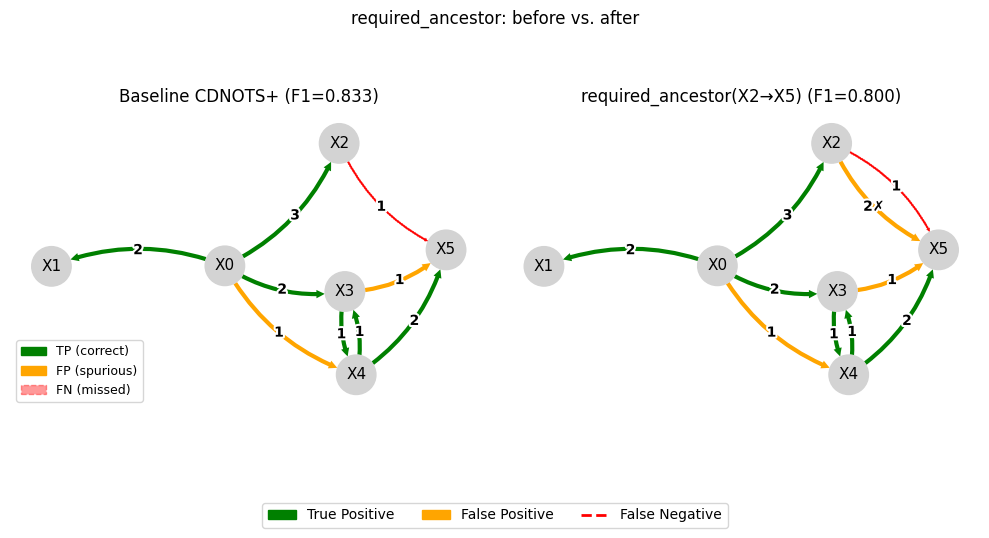

No skeleton path from X2 to X5 existed — the algorithm force-added the direct edge
at the lag with the highest AR-residualized correlation (lag-2 here, not the true lag-1).
This introduces a false-positive lag-2 edge, explaining the F1 drop.


In [8]:
import matplotlib.pyplot as plt
from causalts.plotting.compare import compare_graphs

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
_, _, pos_anc = compare_graphs(
    gt, g, var_names=var_names, fig_ax=(fig, axes[0]),
    title=f"Baseline CDNOTS+ (F1={m['F1']:.3f})",
    node_layout="sfdp", node_label_size=11, node_size=0.2,
    arrow_linewidth=3, legend_loc="lower left", return_pos=True,
)
compare_graphs(
    gt, g_anc, var_names=var_names, fig_ax=(fig, axes[1]),
    title=f"required_ancestor(X2→X5) (F1={m_anc['F1']:.3f})",
    node_pos=pos_anc, node_label_size=11, node_size=0.2,
    arrow_linewidth=3, show_legend=False,
)

import matplotlib.patches as mpatches, matplotlib.lines as mlines
fig.legend(handles=[
    mpatches.Patch(color="green",  label="True Positive"),
    mpatches.Patch(color="orange", label="False Positive"),
    mlines.Line2D([], [], color="red", linestyle="dashed", linewidth=2, label="False Negative"),
], loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.suptitle("required_ancestor: before vs. after", fontsize=12, y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

print("No skeleton path from X2 to X5 existed — the algorithm force-added the direct edge")
print("at the lag with the highest AR-residualized correlation (lag-2 here, not the true lag-1).")
print("This introduces a false-positive lag-2 edge, explaining the F1 drop.")

## Example 5: Forbidden Ancestor (Path Constraint)

The baseline has false-positive edges. With `forbidden_ancestor(A, D)` we
express: *no directed path from A to D may exist in the final graph*.

**Enforcement (two-pass + proactive):**

**Pass 1 — direct + propagated copies:**
Remove A(t-k)→D for all lag copies k AND all lag-shifted copies
(A(t-k-1)→D(t-1), A(t-k-2)→D(t-2), …). CDNOTS propagates edges across lags
when it orients them; this pass removes the direct FP and all its copies
together, preventing autoregressive chains from re-creating indirect paths.

**Pass 2 — genuine multi-hop paths:**
After Pass 1 + Meek, if a path A→…→Y→D still exists through *other* variables,
remove the last-hop Y→D edge.

**Proactive Meek guard:**
During all Meek orientation passes, any edge orientation that would complete a
forbidden path A→…→D is blocked before being applied.

> **Note:** `forbidden_ancestor` is stronger than `forbidden_edge`.  
> Use `forbidden_edge(A, D, ...)` to forbid only the direct connection.  
> Use `forbidden_ancestor(A, D)` only when you are certain no path from A to D
> exists in the true causal graph — otherwise it may remove true-positive edges
> that form indirect A→X→D paths.

Constraints: AncestralKnowledge(forbidden_ancestors=[('X0', 'X4'), ('X3', 'X5'), ('X5', 'X5')])
Forbidden ancestors (baseline FPs): F1=0.778, Precision=1.000, TPR=0.636, SHD=4
Change: F1 0.833 -> 0.778

Each FP edge and all its lag-shifted copies are removed (Pass 1).
If removing those edges leaves a multi-hop path A->X->D still intact,
the last-hop X->D edge is removed in Pass 2.
This can lower F1 if X->D is a true-positive edge shared by another genuine path.
Use add_forbidden_edge() to remove only the direct connection without affecting other paths.


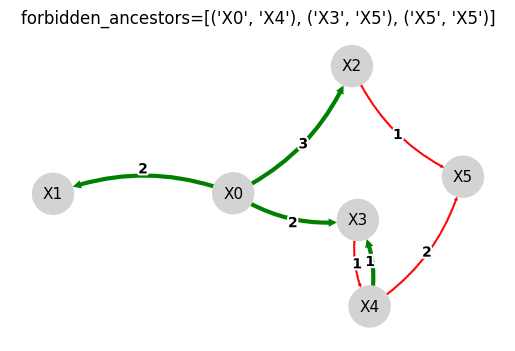

In [ ]:
ak_forb = AncestralKnowledge()
for cause, effect, lag in [(var_names[c], var_names[e], int(l)) for c, e, l in fps]:
    ak_forb.add_forbidden_ancestor(cause, effect)
print("Constraints:", ak_forb)

ci_forb = ParCorrGPU(np.zeros((2, 2)), device="cpu")
res_forb = run_cdnots_plus(
    df=df, indep_test=ci_forb, num_lags=max_lag,
    include_C=False, alpha=0.05, lag_verify=True,
    verbose=False, show_progress=False,
    knowledge=ak_forb,
)
g_forb = res_forb.cg_tig[:d, :d, :]
m_forb = evaluate_graph(g_forb, gt)
print(f"Forbidden ancestors (baseline FPs): F1={m_forb['F1']:.3f}, "
      f"Precision={m_forb['Precision']:.3f}, TPR={m_forb['TPR']:.3f}, SHD={m_forb['SHD']}")
print(f"Change: F1 {m['F1']:.3f} -> {m_forb['F1']:.3f}")
print()
print("Each FP edge and all its lag-shifted copies are removed (Pass 1).")
print("If removing those edges leaves a multi-hop path A->X->D still intact,")
print("the last-hop X->D edge is removed in Pass 2.")
print("This can lower F1 if X->D is a true-positive edge shared by another genuine path.")
print("Use add_forbidden_edge() to remove only the direct connection without affecting other paths.")
compare_graphs(
    gt, g_forb, var_names=var_names,
    title=f"forbidden_ancestors=[('X0', 'X4'), ('X3', 'X5'), ('X5', 'X5')]",
    node_pos=pos_anc, node_label_size=11, node_size=0.2,
    arrow_linewidth=3, show_legend=False,
);

---
## Part 3 — CEDAR: Background Knowledge

CEDAR supports edge-level constraints via its native `forbidden=` / `required=`
parameters (3-tuples `(cause, effect, lag)`) **or** via the unified `knowledge=`
parameter.

**Edge constraints** (`forbidden_edge` / `required_edge`) are enforced during
CEDAR's Cond1/Cond2 CI testing — forbidden candidates are skipped, required
candidates bypass the independence test.

**Path constraints** (`required_ancestor` / `forbidden_ancestor`) are **not
enforced in CEDAR**. When `knowledge=` is passed to `run_cedar`, only the edge
constraints (`_forbidden_edges`, `_required_edges`) are extracted and applied;
ancestral path constraints are silently ignored. Use CDNOTS family if path-level
enforcement is needed.

### Example 6: CEDAR with forbidden and required edges

In [10]:
# --- CEDAR baseline ---
ci_cedar = ParCorrGPU(np.zeros((2, 2)), device="cpu")
res_cedar = run_cedar(
    df=df, ci_test=ci_cedar, max_lag=max_lag,
    alpha_cond1=0.05, alpha_cond2=0.05,
)
g_cedar = res_cedar.cg_tig[:d, :d, :]
m_cedar = evaluate_graph(g_cedar, gt)
print(f"CEDAR Baseline: F1={m_cedar['F1']:.3f}, Precision={m_cedar['Precision']:.3f}, "
      f"TPR={m_cedar['TPR']:.3f}, SHD={m_cedar['SHD']}")

fps_c = np.argwhere((g_cedar == 1) & (gt == 0))
fns_c = np.argwhere((g_cedar == 0) & (gt == 1))
print(f"\nFalse positives ({len(fps_c)}):")
for c, e, l in fps_c:
    print(f"  {var_names[c]} -> {var_names[e]} at lag {l}")
print(f"\nFalse negatives ({len(fns_c)}):")
for c, e, l in fns_c:
    print(f"  {var_names[c]} -> {var_names[e]} at lag {l}")

CEDAR Baseline: F1=0.783, Precision=0.750, TPR=0.818, SHD=5

False positives (3):
  X1 -> X1 at lag 1
  X1 -> X5 at lag 3
  X2 -> X2 at lag 1

False negatives (2):
  X2 -> X5 at lag 1
  X4 -> X5 at lag 2


In [11]:
# --- CEDAR with forbidden + required edges (Option A: native 3-tuple API) ---
cedar_forbidden = [(var_names[c], var_names[e], int(l)) for c, e, l in fps_c]
cedar_required  = [(var_names[c], var_names[e], int(l)) for c, e, l in fns_c]
print("Forbidding:", cedar_forbidden)
print("Requiring:", cedar_required)

ci_cedar2 = ParCorrGPU(np.zeros((2, 2)), device="cpu")
res_cedar2 = run_cedar(
    df=df, ci_test=ci_cedar2, max_lag=max_lag,
    alpha_cond1=0.05, alpha_cond2=0.05,
    forbidden=cedar_forbidden,
    required=cedar_required,
)
g_cedar2 = res_cedar2.cg_tig[:d, :d, :]
m_cedar2 = evaluate_graph(g_cedar2, gt)
print(f"\nCEDAR with BK (native API): F1={m_cedar2['F1']:.3f}, "
      f"Precision={m_cedar2['Precision']:.3f}, TPR={m_cedar2['TPR']:.3f}, SHD={m_cedar2['SHD']}")
print(f"Improvement: F1 {m_cedar['F1']:.3f} -> {m_cedar2['F1']:.3f}")

# --- CEDAR with knowledge= (Option B: AncestralKnowledge API) ---
ak_cedar = res_cedar.make_knowledge(
    forbidden_edges=[(v[0], v[1], v[2], 0) for v in cedar_forbidden],
    required_edges=[(v[0], v[1], v[2], 0) for v in cedar_required],
)
print("\nAncestralKnowledge:", ak_cedar)

ci_cedar3 = ParCorrGPU(np.zeros((2, 2)), device="cpu")
res_cedar3 = run_cedar(
    df=df, ci_test=ci_cedar3, max_lag=max_lag,
    alpha_cond1=0.05, alpha_cond2=0.05,
    knowledge=ak_cedar,
)
g_cedar3 = res_cedar3.cg_tig[:d, :d, :]
m_cedar3 = evaluate_graph(g_cedar3, gt)
print(f"CEDAR with knowledge= API: F1={m_cedar3['F1']:.3f}, "
      f"Precision={m_cedar3['Precision']:.3f}, TPR={m_cedar3['TPR']:.3f}, SHD={m_cedar3['SHD']}")
print("(Both APIs give identical results — knowledge= extracts forbidden/required automatically)")

Forbidding: [('X1', 'X1', 1), ('X1', 'X5', 3), ('X2', 'X2', 1)]
Requiring: [('X2', 'X5', 1), ('X4', 'X5', 2)]

CEDAR with BK (native API): F1=0.917, Precision=0.846, TPR=1.000, SHD=2
Improvement: F1 0.783 -> 0.917

AncestralKnowledge: AncestralKnowledge(forbidden_edges=3, required_edges=2)
CEDAR with knowledge= API: F1=0.917, Precision=0.846, TPR=1.000, SHD=2
(Both APIs give identical results — knowledge= extracts forbidden/required automatically)


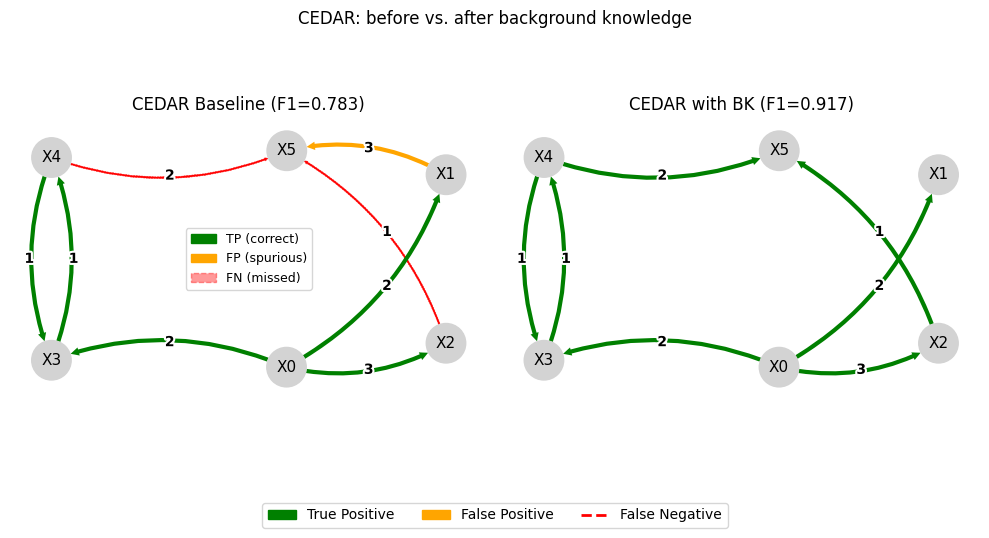

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
_, _, pos_cedar = compare_graphs(
    gt, g_cedar, var_names=var_names, fig_ax=(fig, axes[0]),
    title=f"CEDAR Baseline (F1={m_cedar['F1']:.3f})",
    node_layout="sfdp", node_label_size=11, node_size=0.2,
    arrow_linewidth=3, legend_loc=None, return_pos=True,
)
compare_graphs(
    gt, g_cedar2, var_names=var_names, fig_ax=(fig, axes[1]),
    title=f"CEDAR with BK (F1={m_cedar2['F1']:.3f})",
    node_pos=pos_cedar, node_label_size=11, node_size=0.2,
    arrow_linewidth=3, show_legend=False,
)

fig.legend(handles=[
    mpatches.Patch(color="green",  label="True Positive"),
    mpatches.Patch(color="orange", label="False Positive"),
    mlines.Line2D([], [], color="red", linestyle="dashed", linewidth=2, label="False Negative"),
], loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.suptitle("CEDAR: before vs. after background knowledge", fontsize=12, y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

## Summary

Background knowledge lets you inject domain expertise at two levels:

### Part 1 — Edge constraints (classic API, skeleton phase)

```python
bk = result.make_background_knowledge(
    forbidden=[(cause, effect, cause_lag, effect_lag), ...],
    required=[(cause, effect, cause_lag, effect_lag), ...],
)
run_cdnots_plus(df, indep_test, ..., background_knowledge=bk)
```

Enforced during **skeleton discovery**: forbidden edges are removed before CI
testing; required edges skip CI testing and are always kept.

### Part 2 — Path constraints (`AncestralKnowledge`, post-orientation)

```python
from causalts import AncestralKnowledge

ak = AncestralKnowledge()
ak.add_forbidden_edge("X0", "X4", cause_lag=1)   # removes X0(t-1)→X4 from skeleton
ak.add_required_edge("X2", "X5", cause_lag=1)    # keeps X2(t-1)→X5 in skeleton always
ak.add_required_ancestor("X2", "X5")              # ensures directed X2→…→X5 path exists
ak.add_forbidden_ancestor("X4", "X0")             # removes all directed X4→…→X0 paths

run_cdnots_plus(df, indep_test, ..., knowledge=ak)
```

| Constraint | When enforced | What it does |
|---|---|---|
| `add_forbidden_edge` | Skeleton (pre-CI) | Removes the specific direct edge before CI testing |
| `add_required_edge` | Skeleton (pre-CI) | Keeps the specific direct edge regardless of CI result |
| `add_required_ancestor(A, D)` | Post-orientation | Orients skeleton path / bridges via neighbor / force-adds at AR-residualized best lag |
| `add_forbidden_ancestor(A, D)` | Post-orientation + Meek | Removes direct + lag-shifted A→D edges; last-hop Y→D for multi-hop paths; blocks Meek re-creation |

**`forbidden_edge` vs `forbidden_ancestor`:**
- `forbidden_edge` — forbid only the specific direct A(t-k)→D edge. Other paths are unaffected.
- `forbidden_ancestor` — forbid any path from A to D. Will also remove true-positive intermediary edges (e.g. X→D in A→X→D) if they form part of a forbidden path.

**CEDAR note:** only edge constraints are enforced in CEDAR. Path constraints (`required_ancestor`, `forbidden_ancestor`) are ignored when passed via `knowledge=` to `run_cedar`.